In [ ]:
!pip install roboflow
!pip install ultralytics

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("rooftop-solar-pv-detection").project("rooftop-solar-pv-detection-3yvct")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 141.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.4 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rooftop-Solar-PV-Detection--3 in yolov8:: 100%|██████████| 33206/33206 [00:07<00:00, 4264.77it/s]


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [ ]:
import os
print('Dataset location:', dataset.location)
print('Contents:', os.listdir(dataset.location))

Dataset location: /content/Rooftop-Solar-PV-Detection--3
Contents: ['data.yaml', 'test', 'README.roboflow.txt', 'README.dataset.txt', 'train', 'valid']


In [ ]:
print(open(f'{dataset.location}/data.yaml').read())

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
results = model.train(
    data=f'{dataset.location}/data.yaml',   # points to your downloaded dataset's config
    epochs=30,                               # how many full passes through the data
    imgsz=640,                               # image size YOLOv8 resizes everything to
    batch=16,                                # how many images processed at once (lower if you hit memory errors)
    patience=10,                             # stops early if no improvement for 10 epochs
    project='solar_panel_detector',          # folder name for saved results
    name='run1'
)

In [ ]:
print('Training complete.')
print('Best weights saved at:', results.save_dir)


image 1/1 /content/Screenshot 2026-08-26 132535.png: 640x640 19 SolarPanels, 7.3ms
Speed: 2.9ms preprocess, 7.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-20


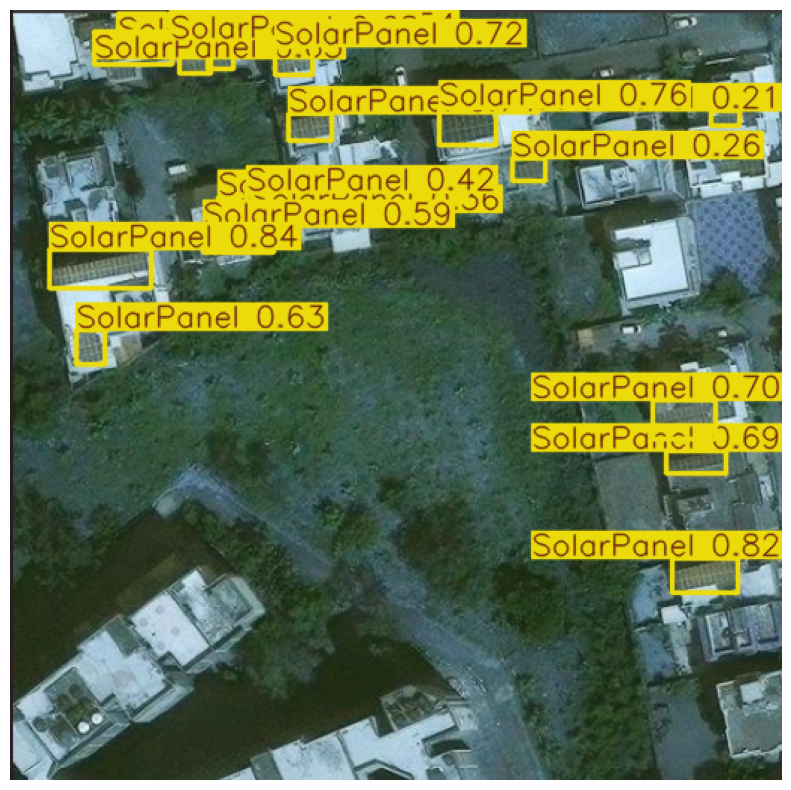

In [ ]:
trained_model = YOLO('/content/best.pt')

# Test on one image from your validation set

test_result = trained_model.predict("/content/Screenshot 2026-08-26 132535.png", conf=0.2, save=True)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.imshow(test_result[0].plot())
plt.axis('off')
plt.show()


In [ ]:
from google.colab import files
files.download(f'{results.save_dir}/weights/best.pt')

NameError: name 'results' is not defined

In [ ]:
from google.colab import files
uploaded = files.upload()  # select your 5 tile screenshots if needed

Saving Screenshot 2026-08-22 175234.png to Screenshot 2026-08-22 175234.png
Saving Screenshot 2026-08-22 175320.png to Screenshot 2026-08-22 175320 (1).png
Saving Screenshot 2026-08-22 175411.png to Screenshot 2026-08-22 175411 (1).png
Saving Screenshot 2026-08-22 175504.png to Screenshot 2026-08-22 175504 (1).png
Saving Screenshot 2026-08-22 175546.png to Screenshot 2026-08-22 175546 (2).png


In [ ]:
filename_map = {
    'tile_17': '/content/Screenshot 2026-08-22 175234.png',
    'tile_18': '/content/Screenshot 2026-08-22 175320.png',
    'tile_19': '/content/Screenshot 2026-08-22 175411.png',
    'tile_21': '/content/Screenshot 2026-08-22 175504.png',
    'tile_22': '/content/Screenshot 2026-08-22 175546.png'
}

solar_detections = {}

for tile_id, filename in filename_map.items():
    result = trained_model.predict(filename, conf=0.25)  # slightly lower conf for a first pass
    solar_detections[tile_id] = result[0].boxes
    print(f'{tile_id}: {len(result[0].boxes)} panels detected')


image 1/1 /content/Screenshot 2026-08-22 175234.png: 352x640 (no detections), 7.3ms
Speed: 2.6ms preprocess, 7.3ms inference, 0.9ms postprocess per image at shape (1, 3, 352, 640)
tile_17: 0 panels detected

image 1/1 /content/Screenshot 2026-08-22 175320.png: 352x640 (no detections), 6.8ms
Speed: 2.3ms preprocess, 6.8ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
tile_18: 0 panels detected

image 1/1 /content/Screenshot 2026-08-22 175411.png: 352x640 (no detections), 6.6ms
Speed: 2.3ms preprocess, 6.6ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
tile_19: 0 panels detected

image 1/1 /content/Screenshot 2026-08-22 175504.png: 352x640 (no detections), 6.9ms
Speed: 2.4ms preprocess, 6.9ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
tile_21: 0 panels detected

image 1/1 /content/Screenshot 2026-08-22 175546.png: 352x640 1 SolarPanel, 6.8ms
Speed: 2.4ms preprocess, 6.8ms inference, 1.5ms postprocess per image at shape (1, 3, 


image 1/1 /content/Screenshot 2026-08-22 175234.png: 352x640 (no detections), 13.2ms
Speed: 3.7ms preprocess, 13.2ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/Screenshot 2026-08-22 175320.png: 352x640 (no detections), 12.1ms
Speed: 5.9ms preprocess, 12.1ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/Screenshot 2026-08-22 175411.png: 352x640 (no detections), 9.5ms
Speed: 3.6ms preprocess, 9.5ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/Screenshot 2026-08-22 175504.png: 352x640 (no detections), 9.4ms
Speed: 3.7ms preprocess, 9.4ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/Screenshot 2026-08-22 175546.png: 352x640 1 SolarPanel, 22.1ms
Speed: 11.4ms preprocess, 22.1ms inference, 2.3ms postprocess per image at shape (1, 3, 352, 640)


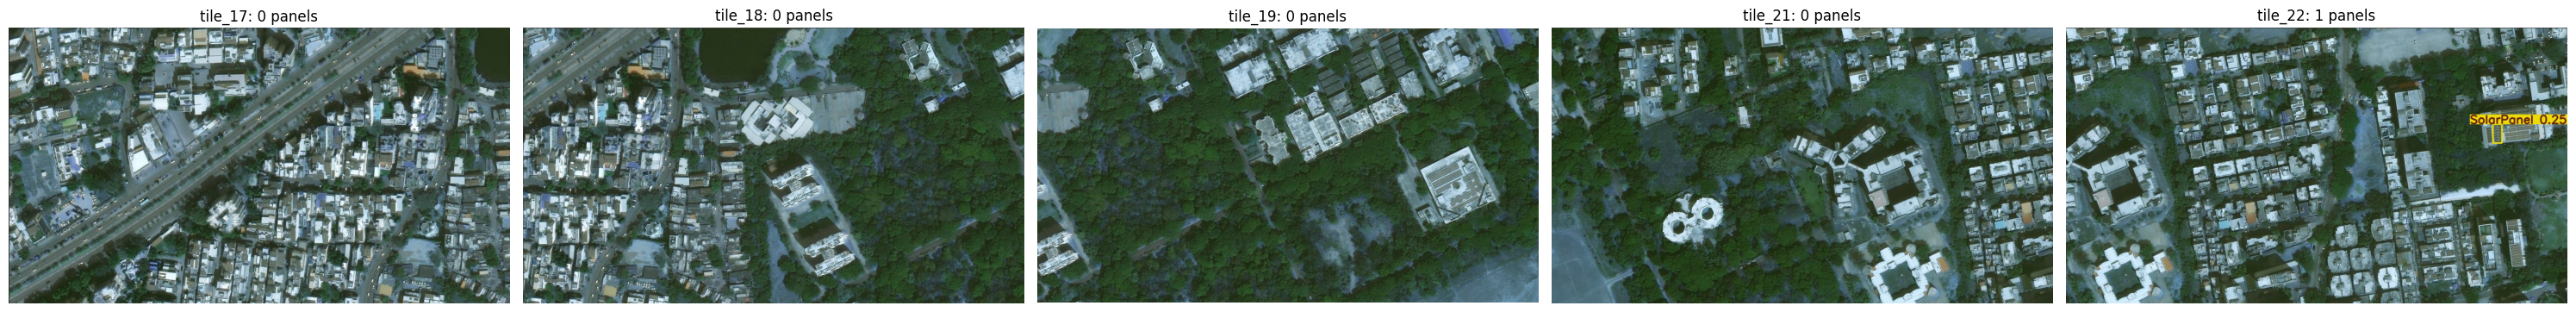

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(30, 6))
for ax, tile_id in zip(axes, filename_map.keys()):
    result = trained_model.predict(filename_map[tile_id], conf=0.25)
    ax.imshow(result[0].plot())
    ax.set_title(f'{tile_id}: {len(result[0].boxes)} panels')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

# 1. Load your custom trained model checkpoint
model = YOLO("/content/best.pt")

# 2. Run validation on your dataset (uses validation split defined in your data.yaml)
metrics = model.val()

# 3. Extract the specific mAP scores
map50_95 = metrics.box.map      # mAP@0.5:0.95 (COCO standard)
map50 = metrics.box.map50      # mAP@0.5
map75 = metrics.box.map75      # mAP@0.75

print(f"mAP@0.5:0.95 -> {map50_95:.4f}")
print(f"mAP@0.5      -> {map50:.4f}")

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2096.0±780.6 MB/s, size: 70.7 KB)
val: Scanning /content/Rooftop-Solar-PV-Detection--3/valid/labels... 442 images, 0 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 442/442 1.3Kit/s 0.3s
val: /content/Rooftop-Solar-PV-Detection--3/valid/images/tile_z18_x183117_y104723_jpg.rf.c0b71ae6dc17f6af2407782f3ea4f1e4.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/Rooftop-Solar-PV-Detection--3/valid/images/tile_z18_x183132_y104728_jpg.rf.9cc1ee201e2e1ee817b63b843662d1a4.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: New cache created: /content/Rooftop-Solar-PV-Detection--3/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2309, len(boxes) = 3089. To resolve this only boxes will b